# **Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import joblib



* pandas → handle CSV data
* numpy → mathematical operations
* matplotlib / seaborn → charts and graphs
* sklearn → ML models and metrics
* xgboost / lightgbm → advanced boosting models
* joblib → save trained model




# Load Dataset

In [3]:
df = pd.read_csv("bigmart.csv")
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


# Check Shape and Columns

In [4]:
print(df.shape)
print(df.columns)

(8523, 12)
Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')


* shape = rows, columns
* columns = feature names

In [5]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [6]:
# Statistical Summary
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


For numeric columns gives:

* mean
* std
* min
* max
* quartiles

Useful to detect outliers or unusual values.

# Missing Values Check

In [7]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


# Fill Missing Values

In [8]:
df["Item_Weight"].fillna(df["Item_Weight"].median(), inplace=True)
df["Outlet_Size"].fillna(df["Outlet_Size"].mode()[0], inplace=True)

Numerical column:
* Use median for Item_Weight.

Categorical column:
* Use mode (most common value) for Outlet_Size.

# Clean Category Labels

In [9]:
df["Item_Fat_Content"] = df["Item_Fat_Content"].replace({
    "LF":"Low Fat",
    "low fat":"Low Fat",
    "reg":"Regular"
})

Same category may have different spellings.
Example:

* LF
* low fat
* Low Fat

All become one clean category.

# EDA: Sales Distribution

---



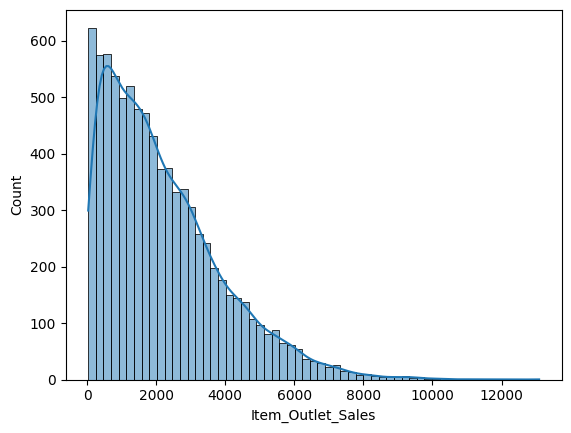

In [10]:
sns.histplot(df["Item_Outlet_Sales"], kde=True)
plt.show()

Shows distribution of target variable (sales).

---



# EDA: Sales vs Outlet Type

---



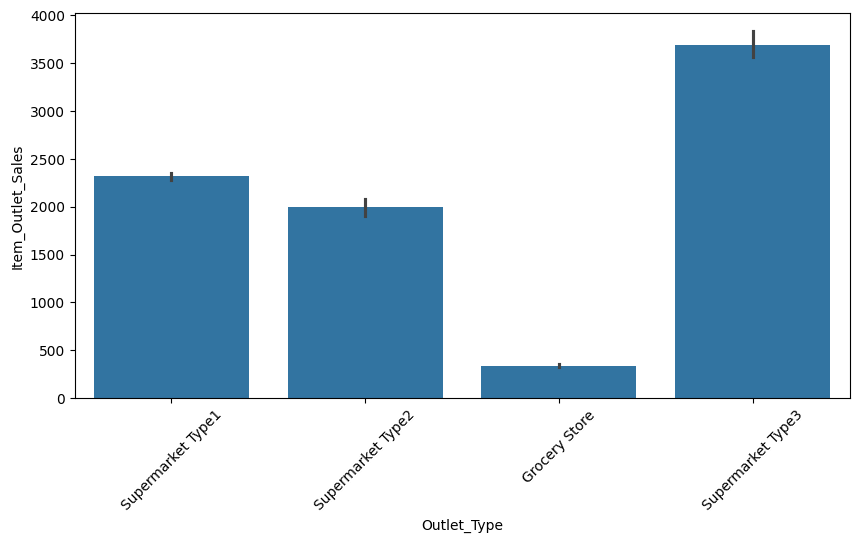

In [11]:
plt.figure(figsize=(10,5))
sns.barplot(x="Outlet_Type", y="Item_Outlet_Sales", data=df)
plt.xticks(rotation=45)
plt.show()

Compares average sales across store types.

---

# EDA: Correlation Heatmap

---



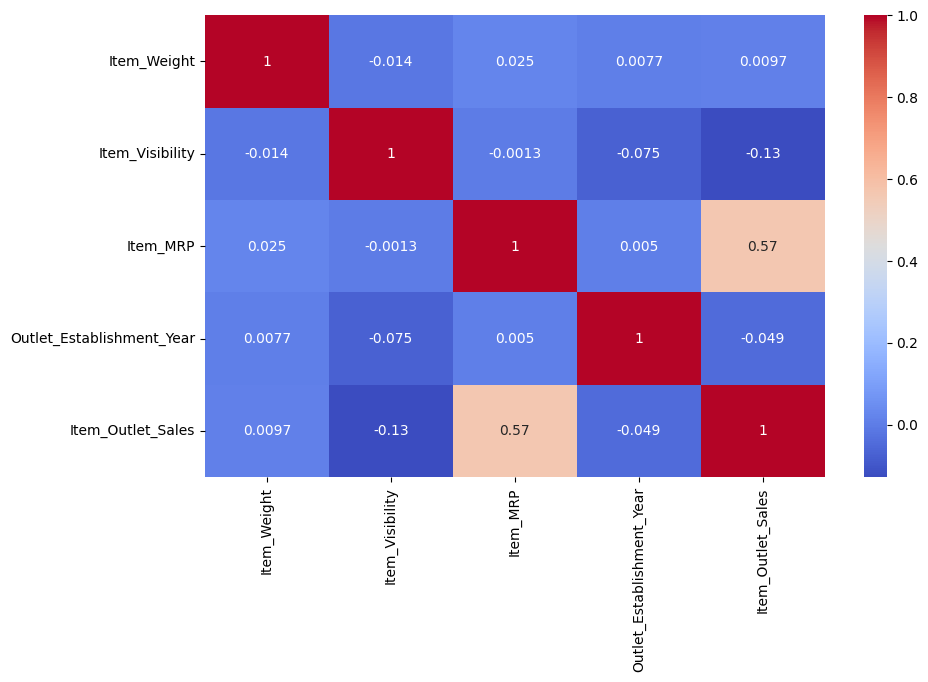

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

Shows relation between numeric columns.

* Closer to +1 = positive relation
* Closer to -1 = negative relation

# Feature Engineering: Store Age

---



In [13]:
df["Store_Age"] = 2026 - df["Outlet_Establishment_Year"]

Creates new column.

Older stores may have:

* More trust
* More customers
* Better sales

# Feature Engineering: Item Category

---



In [14]:
df["Item_Category"] = df["Item_Identifier"].str[:2]

Extract first 2 letters from product ID.

Examples:

* FD = Food
* DR = Drinks
* NC = Non-Consumable

# Fix Zero Visibility

---



In [16]:
df["Item_Visibility"] = df["Item_Visibility"].replace(
    0, df["Item_Visibility"].median()
)
#Visibility = 0 usually unrealistic or missing-like value. Replace with median so data becomes meaningful.

# Drop Unnecessary Columns

---



In [17]:
df.drop(["Item_Identifier", "Outlet_Identifier"], axis=1, inplace=True)

# Convert Categories to Numbers

---



In [18]:
df = pd.get_dummies(df, drop_first=True)

Machine learning models need numbers, not text.

Example:

Outlet_Size:

* Small
* Medium
* High

Becomes columns:

* Outlet_Size_Medium
* Outlet_Size_High

# Separate X and y

---



In [19]:
X = df.drop("Item_Outlet_Sales", axis=1)
y = df["Item_Outlet_Sales"]

* X = input features
* y = target output (sales)

Model learns mapping:
* Features → Sales

# Train/Test Split

---



In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Split data:

* 80% training
* 20% testing

# Train Linear Regression

---



In [21]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

# Train Random Forest

---



In [22]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

Uses many decision trees.

Advantages:

* Strong performance
* Handles non-linear data
* Good default model

# Train XGBoost

---



In [23]:
xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

Advanced boosting algorithm.

Often gives high accuracy in tabular data competitions.

# Train LightGBM

---



In [24]:
lgbm = LGBMRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
lgbm.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001006 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 809
[LightGBM] [Info] Number of data points in the train set: 6818, number of used features: 30
[LightGBM] [Info] Start training from score 2202.365232


LGBMRegressor(learning_rate=0.05, n_estimators=200, random_state=42)

Fast and powerful gradient boosting model.

Good for large datasets.

# Prediction + Evaluation Function

---



In [25]:
def evaluate(model):
    pred = model.predict(X_test)
    print("R2:", r2_score(y_test, pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
    print("MAE:", mean_absolute_error(y_test, pred))

Reusable function to test any model quickly.

Metrics:

* R² higher is better
* RMSE lower is better
* MAE lower is better

# Evaluate Models

---



In [26]:
evaluate(lr)
evaluate(rf)
evaluate(xgb)
evaluate(lgbm)

R2: 0.579810280927396
RMSE: 1068.6735136324037
MAE: 791.2048462896576
R2: 0.5614849668916922
RMSE: 1091.728324149292
MAE: 764.1972816398827
R2: 0.588586779943622
RMSE: 1057.4539314427054
MAE: 735.8875237014842
R2: 0.5949271129377153
RMSE: 1049.2740260929488
MAE: 727.9950739509052


# Stacking Model

---



In [27]:
base_models = [
    ('rf', rf),
    ('xgb', xgb),
    ('lgbm', lgbm)
]

stack = StackingRegressor(
    estimators=base_models,
    final_estimator=LinearRegression()
)

stack.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000218 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 809
[LightGBM] [Info] Number of data points in the train set: 6818, number of used features: 30
[LightGBM] [Info] Start training from score 2202.365232
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000160 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 805
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 30
[LightGBM] [Info] Start training from score 2210.060721
[LightGBM] [Warning] Found

StackingRegressor(estimators=[('rf',
                               RandomForestRegressor(n_estimators=200,
                                                     random_state=42)),
                              ('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma...
                                            learning_rate=0.05, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=200, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                              ('lgbm',
                               LGBMRegressor(learning_rate=0.05,
                                             n_estimators=200,
                                             random_state=42))],
                  final_estimator=LinearRegression())

Combines predictions of multiple models.

Base models:

* Random Forest
* XGBoost
* LightGBM

Meta model:

* Linear Regression

# Evaluate Stacking

---



In [28]:
evaluate(stack)

R2: 0.5980261816239687
RMSE: 1045.2525082054
MAE: 730.8358404415334


Check if stacking performs better than single models.

# Feature Importance

---



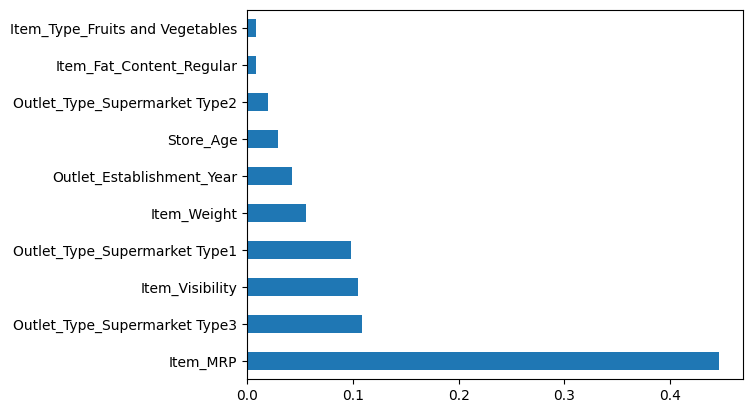

In [29]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.nlargest(10).plot(kind="barh")
plt.show()

Shows top features affecting sales.

Common important features:

* Item_MRP
* Outlet_Type
* Store_Age
* Visibility

# Save Final Model

---



In [30]:
joblib.dump(stack, "bigmart_sales_model.pkl")

['bigmart_sales_model.pkl']

# Sample Prediction

---



In [31]:
sample = X_test.iloc[0:1]
print(stack.predict(sample))

[1232.14766502]
